# Machine Learning Pipeline

Now that we have experience preparing data for input to machine learning libraries, the next step will be to train, tune, and test a model.  You will perform all three of these steps in this hands-on activity.

The assignment consists of the following steps:

1. Load two datasets and prepare their representations and labels for model input. 
2. Split the data into training and testing.
3. Select a model, and identify the parameters to tune.
4. Tune the model.
5. Evaluate the model's performance.

In [2]:
import logging
logging.getLogger("scapy.runtime").setLevel(logging.ERROR)

from netml.pparser.parser import PCAP
from netml.utils.tool import dump_data, load_data

import pandas as pd

## Convert the Packet Capture Into Flows

1. Load the two packet captures for HTTP requests and Log4j scan, 
2. convert them into traffic flows, 
3. generate features from the flow,  
4. label the traffic,
5. normalize your labeled features into a 2D matrix

In [3]:
# Step 1: load the two packet captures.
#   port80.pcap -> ordinary cleartext HTTP browsing        (benign)
#   log4j.pcap  -> Log4j / WordPress scanning traffic      (attack)
# flow_ptks_thres=2 drops flows with a single packet, which have no
# inter-arrival time and would produce empty feature vectors.
normal = PCAP('data/port80.pcap', flow_ptks_thres=2)
scan   = PCAP('data/log4j.pcap',  flow_ptks_thres=2)

# Step 2: group packets into bidirectional flows keyed by the 5-tuple
# (src IP, dst IP, src port, dst port, protocol).
normal.pcap2flows()
scan.pcap2flows()

print(f'port80.pcap -> {len(normal.flows):>5} flows')
print(f'log4j.pcap  -> {len(scan.flows):>5} flows')

port80.pcap ->   148 flows
log4j.pcap  ->  4795 flows


In [4]:
# Step 3: generate features from each set of flows.
#
# We use 'STATS' rather than 'IAT' here on purpose.  netml sizes the IAT
# vector from each capture's own flow-length distribution, so the two
# captures come out with different widths (30 vs 5 columns) and cannot be
# stacked.  'STATS' is a fixed 12-column summary per flow (packet counts,
# byte counts, duration, and IAT/size summary statistics), so both captures
# land in the same feature space.
normal.flow2features('STATS', fft=False, header=False)
scan.flow2features('STATS', fft=False, header=False)

print('benign (port80) features:', normal.features.shape)
print('attack (log4j)  features:', scan.features.shape)

benign (port80) features: (148, 12)
attack (log4j)  features: (4795, 12)


In [5]:
# Step 4: label the traffic and combine into one dataset.
import numpy as np

X = np.vstack([normal.features, scan.features])
y = np.concatenate([
    np.zeros(len(normal.features), dtype=int),   # 0 = benign HTTP
    np.ones(len(scan.features),  dtype=int),     # 1 = Log4j scan
])

print('X:', X.shape, '  y:', y.shape)
counts = dict(zip(*np.unique(y, return_counts=True)))
print('label counts (0=benign, 1=scan):', counts)
print(f'benign share: {(y == 0).mean():.1%}')

# NOTE: the classes are heavily imbalanced (~3% benign).  A model that
# predicts "scan" for everything would already score ~97% accuracy, so
# accuracy alone will be misleading -- keep this in mind for the confusion
# matrix / ROC / AUC sections below.

X: (4943, 12)   y: (4943,)
label counts (0=benign, 1=scan): {np.int64(0): np.int64(148), np.int64(1): np.int64(4795)}
benign share: 3.0%


In [6]:
# Step 5: normalize the labeled features into a 2D matrix ready for sklearn.
from sklearn.preprocessing import StandardScaler

# STATS mixes units (counts, bytes, seconds) across wildly different scales,
# so standardize each column to zero mean and unit variance.
X_scaled = StandardScaler().fit_transform(X)

print('normalized feature matrix:', X_scaled.shape)
pd.DataFrame(X_scaled).describe().iloc[:, :6]

# NOTE: this fits the scaler on all of the data for simplicity.  To avoid
# leaking test-set statistics into training, the cleaner pattern is to split
# first, then fit the scaler on the training set only and apply it to both.

normalized feature matrix: (4943, 12)


,0,1,2,3,4,5
count,4.943000e+03,4.943000e+03,4.943000e+03,4.943000e+03,4.943000e+03,4.943000e+03
mean,-3.162440e-17,-2.012462e-16,-1.796841e-16,1.685293e-14,1.997656e-14,4.599913e-17
std,1.000101e+00,1.000101e+00,1.000101e+00,1.000101e+00,1.000101e+00,1.000101e+00
min,-8.571566e-01,-8.046953e-02,-8.491997e-02,-7.782597e-01,-9.594590e-01,-3.565271e-01
25%,-7.770388e-01,-8.024200e-02,-8.473218e-02,-4.684043e-01,-9.594590e-01,-2.013119e-01
50%,-2.454469e-01,-8.017513e-02,-8.429645e-02,-9.768439e-02,-2.319621e-02,-4.609669e-02
75%,3.555421e-01,-7.699597e-02,-7.943077e-02,2.820268e-01,7.659660e-01,-4.609669e-02
max,8.080638e+00,2.399060e+01,2.525506e+01,1.260006e+01,5.785362e+00,1.772605e+01


## Evaluating a Machine Learning Model

The goal of supervised learning is to train a model that takes examples and predicts labels for these examples that are as close as possible to the actual labels. For instance, in this example above, a model might take features from a traffic trace and predict whether the traffic constitutes regular web traffic or a scan.

How do you measure whether the model is succeeding if you don't know the true labels for new observations? The way to solve this problem is to test the performance of the trained algorithm on additional data that it has never seen, but for which you already know the correct labels. 

This requires that you train the algorithm using only a portion of the entire labeled dataset (the **training set**) and withold the rest of the labeled data (the **test set**) for testing how well the model generalizes to new information. 

To evaluate the model, we will need to split the data into train and test sets.

### Split into Training and Test Sets

Split your data into a training and test set using scikit-learn. A common split is to train on 80% of your data, while withholding 20% of the data. 

In [7]:
# Split into a training set (80%) and a held-out test set (20%).
from sklearn.model_selection import train_test_split

# stratify=y preserves the ~3% benign share in BOTH splits.  Without it a
# random split can leave the test set with almost no benign flows, which
# would make the confusion matrix and ROC below mostly noise.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y,
)

print(f'train: {X_train.shape}    test: {X_test.shape}')
for name, split in [('train', y_train), ('test', y_test)]:
    n_benign, n_scan = int((split == 0).sum()), int((split == 1).sum())
    print(f'{name:>5}: {n_benign:>4} benign / {n_scan:>4} scan   ({n_benign / len(split):.1%} benign)')

# Only ~30 benign flows land in the test set, so treat small differences in
# the metrics below as noise rather than signal.

train: (3954, 12)    test: (989, 12)
train:  118 benign / 3836 scan   (3.0% benign)
 test:   30 benign /  959 scan   (3.0% benign)


### Training Your Model

Now that you have split your data into training and testing sets, you are ready to train and evaluate a model. 

Import a machine learning model of your choice, use your training set to train the model, and use the test set to evaluate it. 

In [8]:
# Select, train, and tune the model.
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import numpy as np

# A random forest suits these features: STATS mixes counts, byte totals and
# durations on very different scales, and trees are scale-invariant, so no
# feature dominates just by having larger units.
#
# class_weight='balanced' reweights the classes inversely to their frequency.
# Without it the forest can score ~97% accuracy by always predicting "scan".
rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

# The parameters we chose to tune: how many trees, how deep they may grow,
# and how much evidence a leaf needs (the last two both limit overfitting).
param_grid = {
    'n_estimators':     [100, 300],
    'max_depth':        [None, 5, 10],
    'min_samples_leaf': [1, 2, 5],
}

# Tune by cross-validation on the TRAINING set only -- the test set stays
# untouched until the evaluation section.  Scored by ROC AUC rather than
# accuracy, which is close to meaningless at a 97/3 class split.
search = GridSearchCV(
    rf, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1,
)
search.fit(X_train, y_train)

model = search.best_estimator_
print('best parameters:', search.best_params_)
print(f'best cross-validated ROC AUC: {search.best_score_:.4f}')

# Which flow statistics actually separate scanning from browsing?
stats_names = ['duration', 'pkts_rate', 'bytes_rate', 'mean_size', 'std_size',
               'q1_size', 'q2_size', 'q3_size', 'min_size', 'max_size',
               'num_pkts', 'num_bytes']
print('\ntop features:')
for i in np.argsort(model.feature_importances_)[::-1][:5]:
    print(f'  {stats_names[i]:>12s}  {model.feature_importances_[i]:.3f}')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/homebrew/lib/python3.11/site-packages/joblib/externals/loky/backend/popen_loky_posix.py", line 180, in <module>
    exitcode = process_obj._bootstrap()
  File "/opt/homebrew/Cellar/python@3.11/3.11.13/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/homebrew/Cellar/python@3.11/3.11.13/Frameworks/Python.framework/Version

best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300}
best cross-validated ROC AUC: 0.9996

top features:
     pkts_rate  0.256
    bytes_rate  0.169
     num_bytes  0.144
      duration  0.121
       q2_size  0.065


### Test Your Trained Model

You can now evaluate how well your trained model works.  There are several valuable ways to visualize your results. You might use techniques such as a confusion matrix, or a receiver operating characteristic (ROC) curve. Below we will gain some experience plotting both of those.  This [documentation](https://scikit-learn.org/stable/auto_examples/miscellaneous/plot_display_object_visualization.html) may help you with plotting these results.

#### Confusion Matrix 

A confusion matrix is a one way to understand errors of different types. We can see a lot of examples off diagonal, suggesting a fair number of incorrect answers.

accuracy:          0.9970
always-"scan" acc: 0.9697   <- the number to beat

              precision    recall  f1-score   support

      benign      1.000     0.900     0.947        30
        scan      0.997     1.000     0.998       959

    accuracy                          0.997       989
   macro avg      0.998     0.950     0.973       989
weighted avg      0.997     0.997     0.997       989



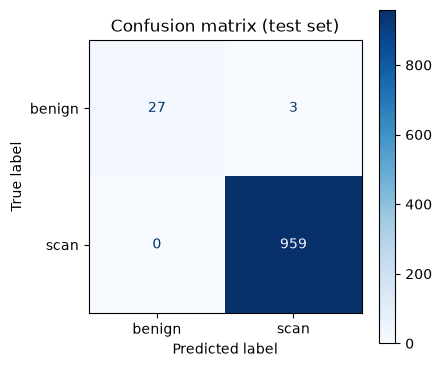

In [9]:
# Evaluate the tuned model on the held-out test set.
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score

y_pred = model.predict(X_test)

# Probability of the positive class (scan).  The ROC and precision-recall
# curves below need these scores, not the hard 0/1 predictions.
y_score = model.predict_proba(X_test)[:, 1]

# Always predicting "scan" would already score this much -- the bar that
# accuracy has to clear before it means anything on this dataset.
baseline = (y_test == 1).mean()
print(f'accuracy:          {accuracy_score(y_test, y_pred):.4f}')
print(f'always-"scan" acc: {baseline:.4f}   <- the number to beat')
print()
print(classification_report(y_test, y_pred, target_names=['benign', 'scan'], digits=3))

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))

# Left: raw counts, so the actual size of each error is visible.
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['benign', 'scan'], cmap='Blues',
    ax=axes[0], colorbar=False,
)
axes[0].set_title('Counts')

# Right: the SAME matrix with each row divided by its own total.
# normalize='true' means "normalize over the true labels", i.e. over rows --
# so each diagonal cell is exactly that class's recall.  The benign row
# therefore reads 0.90 directly, which is the 27/30 from the left panel.
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['benign', 'scan'], cmap='Blues',
    ax=axes[1], colorbar=False, normalize='true', values_format='.3f',
)
axes[1].set_title('Row-normalized (diagonal = recall)')

fig.suptitle('Confusion matrix (test set)')
plt.tight_layout()

# Read the off-diagonal cells: the top-right is benign flows wrongly flagged
# as scanning (false positives), the bottom-left is scans that slipped
# through (false negatives).  With only 30 benign flows in the test set, a
# single misclassification moves benign recall by ~3.3 points, so benign
# recall can only ever land on 0.900, 0.933, 0.967 or 1.000.

#### Receiver Operating Characteristic

Some models can output different classes based on a threshold that is set for the decision. 

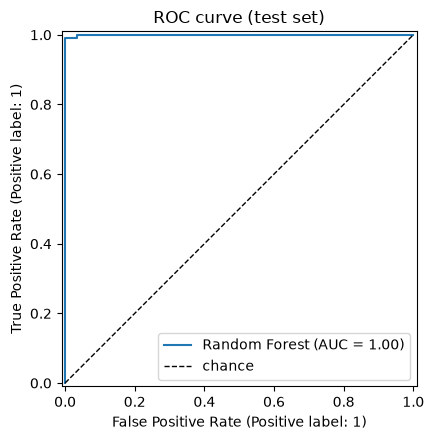

In [10]:
# The ROC curve sweeps the decision threshold and plots, at every setting,
# the true positive rate against the false positive rate.
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(5, 4.5))
RocCurveDisplay.from_predictions(y_test, y_score, name='Random Forest', ax=ax)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='chance')
ax.set_title('ROC curve (test set)')
ax.legend(loc='lower right')
plt.tight_layout()

# Note what the FPR denominator is here: all 959 scan flows.  Because the
# negative class is so much larger than the benign class, a large number of
# false positives still moves the FPR only slightly -- which is exactly why
# this curve looks flattering on imbalanced data.

#### Area Under the Curve (AUC)

From the ROC above, you can also compute a metric called the area under the curve (AUC). Visually, this is the area under the curve that you just plotted. You could see, intuitively, that the "best" performance should yield an AUC of 1, and the worst performance would yield an AUC closer to 0.5.

Scikit learn also has a function for computing AUC.  Compute the area under the curve.

In [11]:
# Area under the ROC curve: 1.0 is perfect, 0.5 is chance.
from sklearn.metrics import roc_auc_score

test_auc = roc_auc_score(y_test, y_score)
print(f'ROC AUC (test):             {test_auc:.4f}')
print(f'ROC AUC (cross-validated):  {search.best_score_:.4f}')

# The two agree closely, so the model is not simply overfitting the training
# split.  It is worth being sceptical of a number this high all the same: the
# two classes come from two separate capture files, so the forest may be
# keying on capture-level artifacts (timing, MTU, the particular hosts) as
# much as on "scanning versus browsing" as a general behaviour.  A capture
# taken elsewhere would be the real test.

ROC AUC (test):             0.9997
ROC AUC (cross-validated):  0.9996


#### Precision and Recall

ROC and AUC can both look excellent on imbalanced data. The false positive rate divides by the number of true negatives, and with 959 scan flows against 30 benign ones that denominator is large enough to hide a lot of mistakes.

Precision and recall ignore the true negatives entirely, which is what makes them the more honest view here:

- **Precision** — of the flows the model flagged as scanning, what fraction really were? This is the one an analyst feels, because low precision means chasing false alarms.
- **Recall** — of the scans that were actually present, what fraction did we catch?

The two trade off against each other as you move the threshold, and the precision-recall curve shows that trade-off directly. Its baseline is not the diagonal: a model guessing at random scores the positive class's own prevalence, so on this test set the floor is about 0.97, not 0.5. **Average precision (AP)** summarises the curve the way AUC summarises the ROC.

Because the interesting failure here is missing benign traffic rather than missing scans, it is worth plotting the curve for *both* classes.

average precision, scan   (chance = 0.970): 1.0000
average precision, benign (chance = 0.030): 0.9930


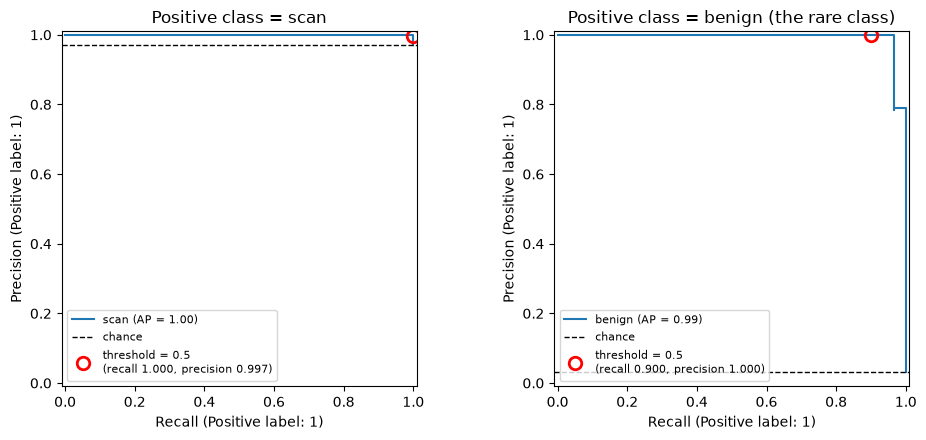

In [13]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score
from sklearn.metrics import precision_score, recall_score

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# Left: "scan" as the positive class -- the flattering view, since scans are
# 97% of the test set.
PrecisionRecallDisplay.from_predictions(y_test, y_score, name='scan', ax=axes[0])
axes[0].axhline((y_test == 1).mean(), ls='--', c='k', lw=1, label='chance')
axes[0].set_title('Positive class = scan')

# Right: "benign" as the positive class -- the hard problem.  Flip both the
# labels and the scores so that benign becomes the class being detected.
y_benign = (y_test == 0).astype(int)
PrecisionRecallDisplay.from_predictions(y_benign, 1 - y_score, name='benign', ax=axes[1])
axes[1].axhline(y_benign.mean(), ls='--', c='k', lw=1, label='chance')
axes[1].set_title('Positive class = benign (the rare class)')

# The curve sweeps EVERY threshold; the classification_report above uses just
# one of them (predict() splits at p = 0.5).  Mark that single operating
# point on each panel, otherwise there is no way to see which point on the
# curve produced the reported precision and recall.
for ax, yt, yp in [(axes[0], y_test, y_pred), (axes[1], y_benign, (y_pred == 0).astype(int))]:
    p, r = precision_score(yt, yp), recall_score(yt, yp)
    ax.plot(r, p, 'o', ms=9, mfc='none', mec='red', mew=2,
            label=f'threshold = 0.5\n(recall {r:.3f}, precision {p:.3f})')
    ax.legend(loc='lower left', fontsize=8)

plt.tight_layout()

ap_scan   = average_precision_score(y_test, y_score)
ap_benign = average_precision_score(y_benign, 1 - y_score)
print(f'average precision, scan   (chance = {(y_test == 1).mean():.3f}): {ap_scan:.4f}')
print(f'average precision, benign (chance = {y_benign.mean():.3f}): {ap_benign:.4f}')

# Compare each AP against its own chance line, not against the other.  The
# scan number sits just above an already very high floor, so it says little;
# the benign number starts from a floor near 0.03, so any lift there is a
# genuine result.
#
# The red circle on the right panel is the 0.900 benign recall from the
# classification report.  Moving along that curve away from the circle is
# what changing the threshold would buy you.

## Thought Question

Which evaluation model is more appropriate, and when (i.e., under what circumstances)? When might you care more about looking at the confusion matrix (or model accuracy) vs. the ROC, or the area under the curve?

ROC/AUC are not evaluation tools because of class imbalance (3.0% of cases are benign/HTPP). PR curves are better.